# Reward Composition Failures

Modern RL training pipelines compose multiple reward signals into a single scalar. Format checkers, correctness verifiers, LLM judges, safety classifiers. They get summed with hand-tuned weights and the result drives gradient updates.

This notebook shows three ways that composition breaks. Each scenario reproduces a documented real-world failure. The failures are not in the individual components. They work fine on their own. The problem is in how they are combined.

We use a 1D bandit policy to make the reward landscapes visible. The composition dynamics we study do not depend on model complexity. A weighted sum is a weighted sum whether the policy is a bandit or a 70B language model.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (10, 4), 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 120,
})
C = {'broken': '#d62728', 'fixed': '#2ca02c', 'format': '#ff7f0e',
     'correctness': '#1f77b4', 'style': '#9467bd', 'safety': '#e377c2',
     'gray': '#7f7f7f'}

from src.composition import WeightedSumCompositor, GatedCompositor, run_bandit
from src.scenarios import (
    priority_inversion_broken, priority_inversion_fixed,
    gradient_dominance_broken, gradient_dominance_fixed,
    signal_degradation_broken, signal_degradation_fixed,
)

## 1. Priority Inversion

Zhang et al. (2025) trained a medical QA model with two rewards summed together. Format compliance (are the XML tags correct?) and correctness (is the answer right?). Within hundreds of steps the model converged on a degenerate strategy: produce correctly formatted but trivially short answers. Format has a sharper gradient. It dominates early training. The model gets stuck.

They called it the Direct Answer Hacker. We reproduce the dynamic below.

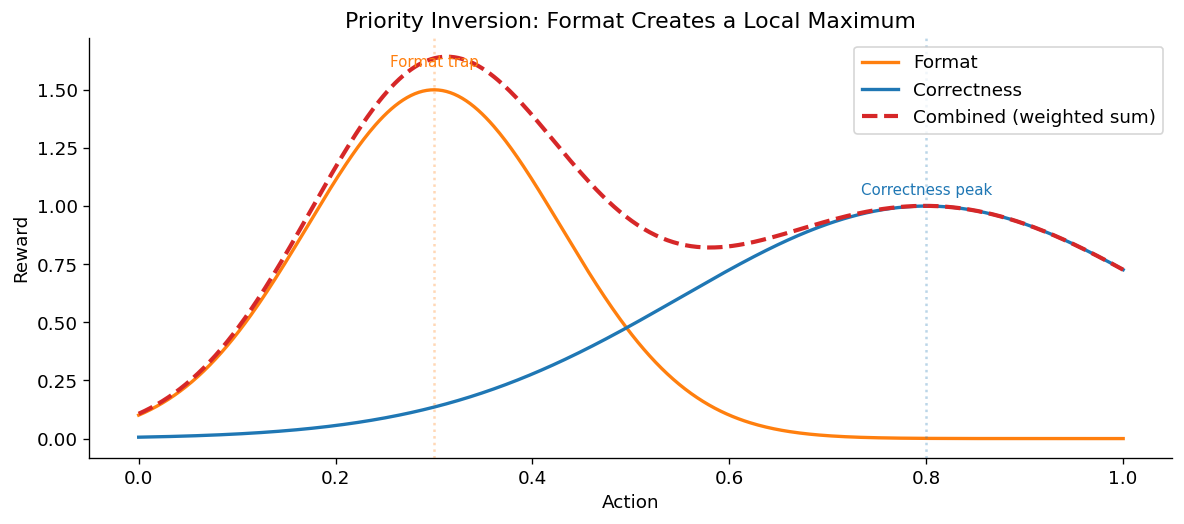

In [2]:
actions = np.linspace(0, 1, 500)
comps = priority_inversion_broken()
baseline = WeightedSumCompositor(comps)

fmt = [comps[0].fn(a) for a in actions]
cor = [comps[1].fn(a) for a in actions]
tot = [baseline.compose(a)['reward'] for a in actions]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(actions, fmt, color=C['format'], lw=2, label='Format')
ax.plot(actions, cor, color=C['correctness'], lw=2, label='Correctness')
ax.plot(actions, tot, color=C['broken'], lw=2.5, ls='--', label='Combined (weighted sum)')
ax.axvline(0.3, color=C['format'], alpha=0.3, ls=':')
ax.axvline(0.8, color=C['correctness'], alpha=0.3, ls=':')
ax.annotate('Format trap', xy=(0.3, 1.6), ha='center', fontsize=9, color=C['format'])
ax.annotate('Correctness peak', xy=(0.8, 1.05), ha='center', fontsize=9, color=C['correctness'])
ax.set_xlabel('Action'); ax.set_ylabel('Reward')
ax.set_title('Priority Inversion: Format Creates a Local Maximum')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

The combined reward peaks at 0.3, not 0.8. A policy optimizing the sum converges to the format attractor. Training across 30 seeds confirms this is consistent, not a fluke.

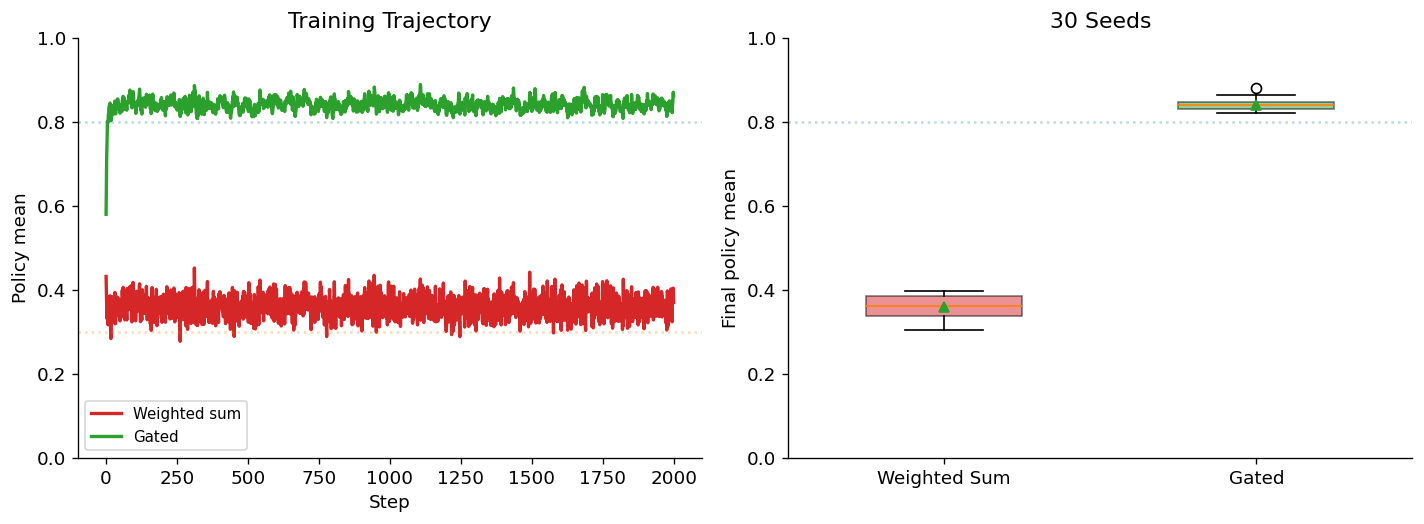

Weighted sum trapped: 30/30 (100%)
Gated mean: 0.840


In [3]:
adhoc_finals, fixed_finals = [], []
for seed in range(30):
    h1 = run_bandit(WeightedSumCompositor(priority_inversion_broken()), n_steps=2000, seed=seed)
    h2 = run_bandit(GatedCompositor(priority_inversion_fixed(), monitor=False), n_steps=2000, seed=seed)
    adhoc_finals.append(h1['policy_mu'][-1])
    fixed_finals.append(h2['policy_mu'][-1])

h_b = run_bandit(WeightedSumCompositor(priority_inversion_broken()), n_steps=2000, seed=42)
h_f = run_bandit(GatedCompositor(priority_inversion_fixed(), monitor=False), n_steps=2000, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(h_b['step'], h_b['policy_mu'], color=C['broken'], lw=2, label='Weighted sum')
ax.plot(h_f['step'], h_f['policy_mu'], color=C['fixed'], lw=2, label='Gated')
ax.axhline(0.3, color=C['format'], alpha=0.3, ls=':'); ax.axhline(0.8, color=C['correctness'], alpha=0.3, ls=':')
ax.set_xlabel('Step'); ax.set_ylabel('Policy mean'); ax.set_ylim(0,1)
ax.set_title('Training Trajectory'); ax.legend(fontsize=9)

ax = axes[1]
bp = ax.boxplot([adhoc_finals, fixed_finals], positions=[1,2], widths=0.5, patch_artist=True, showmeans=True)
bp['boxes'][0].set(facecolor=C['broken'], alpha=0.5); bp['boxes'][1].set(facecolor=C['fixed'], alpha=0.5)
ax.axhline(0.8, color=C['correctness'], alpha=0.3, ls=':')
ax.set_xticks([1,2]); ax.set_xticklabels(['Weighted Sum', 'Gated'])
ax.set_ylabel('Final policy mean'); ax.set_ylim(0,1); ax.set_title('30 Seeds')
plt.tight_layout(); plt.show()

trapped = sum(1 for f in adhoc_finals if f < 0.5)
print(f"Weighted sum trapped: {trapped}/30 ({100*trapped/30:.0f}%)")
print(f"Gated mean: {np.mean(fixed_finals):.3f}")

## 2. Gradient Dominance

Three reward components with different variance profiles. A style judge (high variance, steep gradient) dominates gradient updates even though its nominal weight is lowest. The policy converges toward style preferences instead of correctness.

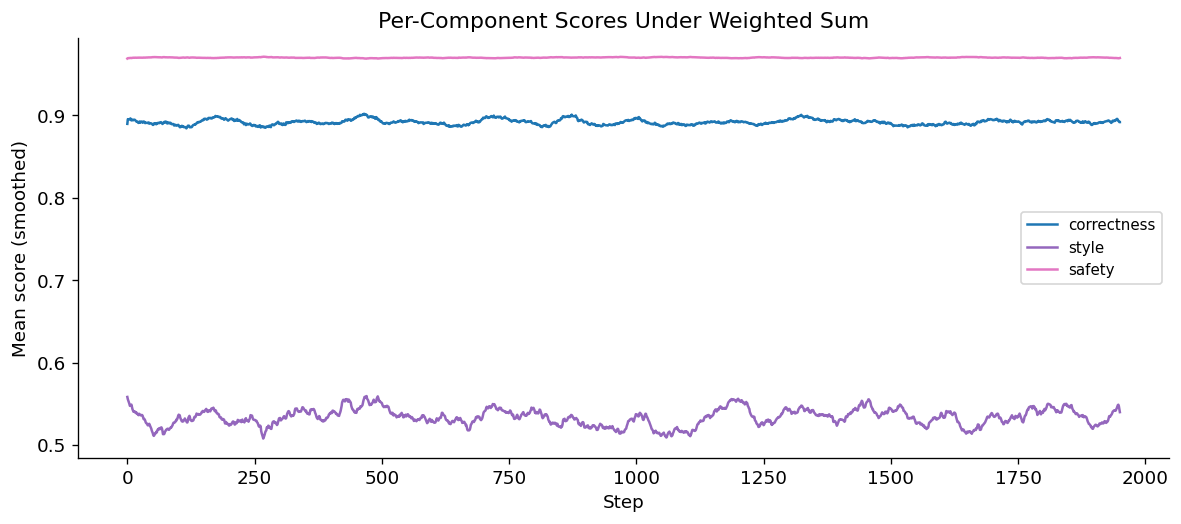

Final policy position: 0.733 (style peaks at 0.5, correctness at 0.7)


In [4]:
rng = np.random.RandomState(42)
h = run_bandit(WeightedSumCompositor(gradient_dominance_broken(rng)), n_steps=2000, seed=42)

fig, ax = plt.subplots(figsize=(10, 4.5))
w = 50
for name, color in [('correctness', C['correctness']), ('style', C['style']), ('safety', C['safety'])]:
    s = np.convolve(h['scores'][name], np.ones(w)/w, mode='valid')
    ax.plot(range(len(s)), s, color=color, lw=1.5, label=name)
ax.set_xlabel('Step'); ax.set_ylabel('Mean score (smoothed)')
ax.set_title('Per-Component Scores Under Weighted Sum')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f"Final policy position: {h['policy_mu'][-1]:.3f} (style peaks at 0.5, correctness at 0.7)")

## 3. Signal Degradation

A safety classifier calibrated at step 0 becomes permissive as the policy drifts over training. The composition keeps reporting high safety while actual detection accuracy drops from 0.95 to 0.40.

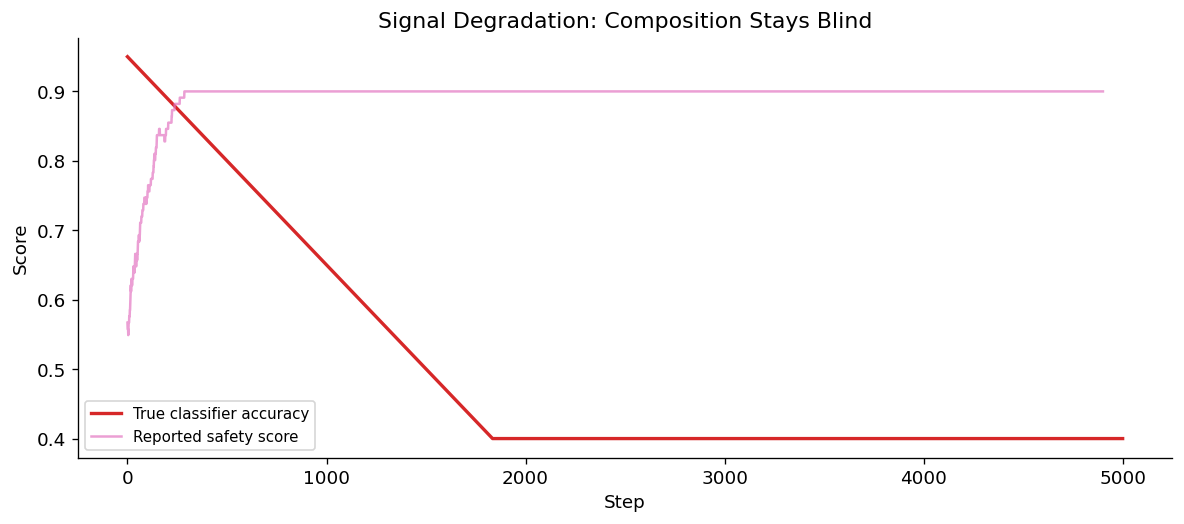

Accuracy: 0.95 -> 0.40
Reported safety at end: 0.90


In [5]:
comps, ctr = signal_degradation_broken(0.0003)
baseline = WeightedSumCompositor(comps)
rng, n_steps, mu = np.random.RandomState(42), 5000, 0.5
true_acc, reported = [], []

for step in range(n_steps):
    ctr['step'] = step
    a = np.clip(rng.normal(mu, 0.15), 0, 1)
    r = baseline.compose(a, step=step)
    true_acc.append(max(0.4, 0.95 - 0.0003*step))
    reported.append(r['scores']['safety'])
    mu = np.clip(mu + 0.001*(r['reward']-0.5), 0, 1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(n_steps), true_acc, color=C['broken'], lw=2, label='True classifier accuracy')
w = 100
smooth = np.convolve(reported, np.ones(w)/w, mode='valid')
ax.plot(range(len(smooth)), smooth, color=C['safety'], lw=1.5, alpha=0.7, label='Reported safety score')
ax.set_xlabel('Step'); ax.set_ylabel('Score')
ax.set_title('Signal Degradation: Composition Stays Blind')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f"Accuracy: {true_acc[0]:.2f} -> {true_acc[-1]:.2f}")
print(f"Reported safety at end: {reported[-1]:.2f}")

## Summary

| Scenario | Real-World Instance | What Breaks |
|----------|-------------------|-------------|
| Priority inversion | Med-RLVR Direct Answer Hacker | Prerequisite treated as optimization target |
| Gradient dominance | DeepSeek-R1 length gaming | High-variance component pulls training |
| Signal degradation | Wen et al. misleading evaluators | Fixed weight for a deteriorating signal |

These are not edge cases. They are the default outcome of ad-hoc weighted sums when components have different gradient profiles, different variance, or different shelf lives. The next notebook shows the fixes.